INTELIGENCIA ARTIFICIAL Y REDES NEURONALES

EXAMEN DE MEDIO CURSO

HECTOR GERARDO QUIÑONES ROMO - 2132258

HORA: N4

In [27]:
#Importar librerías necesarias para análisis de datos y creación de gráficas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
#Leer el archivo CSV que contiene los datos de los sensores del robot
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv')


In [29]:
#Mostrar las primeras 5 filas del conjunto de datos
print(df.head(5))

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [30]:
#Mostrar la cantidad de valores nulos en cada columna del DataFrame
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [31]:
#Mostrar tipos de datos de cada columna
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


In [32]:
#Calcular la mediana de horsepower
mediana_hp = np.median(df["horsepower"].dropna())

#Reemplazar valores nulos con la mediana
df["horsepower"].fillna(mediana_hp, inplace=True)

#Verificar que ya no haya valores nulos
print(df["horsepower"].isnull().sum())

0


/tmp/ipykernel_193/4226486185.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["horsepower"].fillna(mediana_hp, inplace=True)


In [33]:
#Crear relación peso-potencia
df["relacion_peso_potencia"] = df["weight"] / df["horsepower"]

#Mostrar algunas filas para verificar
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  relacion_peso_potencia  
0          70    usa  chevrolet chevelle malibu               26.953846  
1          70    usa          buick skylark 320               22.381818  
2          70    usa         plymouth satellite               22.906667  
3          70    usa              amc rebel sst               22.886667  
4          70    usa                ford torino               24.635714  


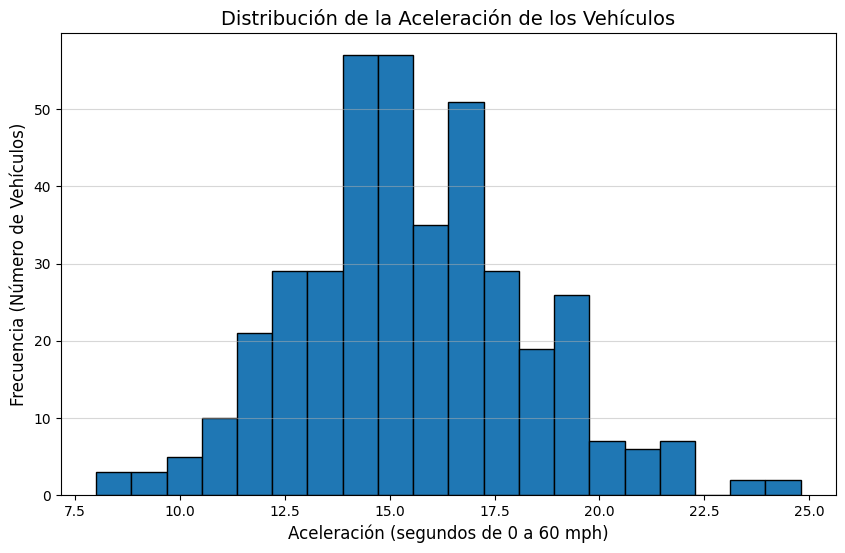

In [34]:
#Histograma
plt.figure(figsize=(10,6))

plt.hist(df['acceleration'].dropna(), bins=20, edgecolor='black')

plt.title('Distribución de la Aceleración de los Vehículos', fontsize=14)
plt.xlabel('Aceleración (segundos de 0 a 60 mph)', fontsize=12)
plt.ylabel('Frecuencia (Número de Vehículos)', fontsize=12)

plt.grid(axis='y', alpha=0.5)

plt.show()



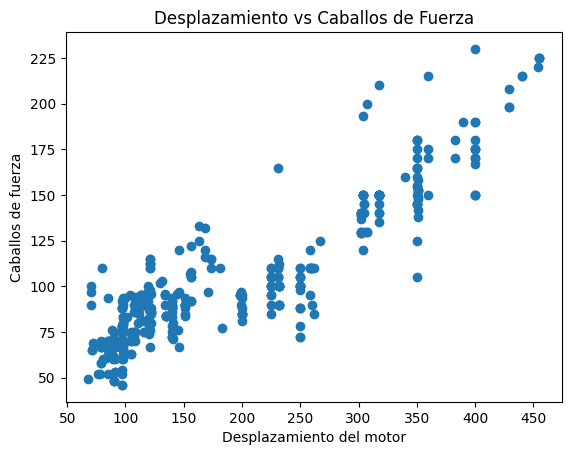

In [35]:
#Grafico de Dispersion
plt.figure()

plt.scatter(df["displacement"], df["horsepower"])

plt.title("Desplazamiento vs Caballos de Fuerza")
plt.xlabel("Desplazamiento del motor")
plt.ylabel("Caballos de fuerza")

plt.show()


In [36]:
#Primero se agrupa con PANDAS
promedio_mpg = df.groupby("origin")["mpg"].mean()
print(promedio_mpg)

origin
europe    27.891429
japan     30.450633
usa       20.083534
Name: mpg, dtype: float64


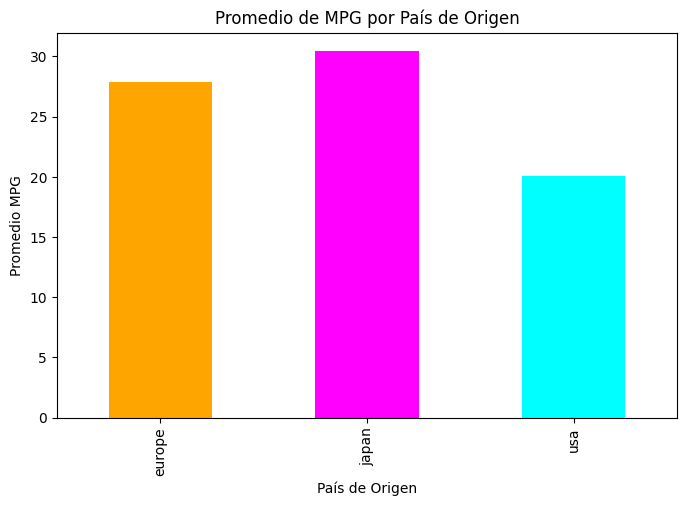

In [37]:
#Grafico de Barras
plt.figure(figsize=(8,5))

colores = ['orange', 'magenta', 'cyan']

promedio_mpg.plot(kind='bar', color=colores)

plt.title("Promedio de MPG por País de Origen")
plt.xlabel("País de Origen")
plt.ylabel("Promedio MPG")

plt.show()

